# 05 -- one site's final transfer function

This workbook reads every transfer function one site has -- workbook 03's reference kinds at both rates and
every selection of hours a 10 Hz pass ran on, and workbook 04's forms -- puts the same three tests to all of
them, proposes one per component, records the choice that was made, and writes one EDI.

| word | what it is | code key |
|---|---|---|
| remote site | one other site's H as the reference | `remote` |
| fleet stack | a coherence-weighted mean of several sites' H | `stack` |
| observatory | an INTERMAGNET one-second record as the reference | `obs` |
| stack + observatory | the stack with the observatory as a member | `stack_obs` |

The single station is not a kind of this package: it is biased low by whatever noise sits in H, and its error
bars do not show that bias. A single-station file an earlier pass left in a run folder is counted, named and
read by nothing here.

The three tests are the ones students learn first -- the phase in its quadrant, the apparent resistivity
changing no faster than the period, and the error bar -- and a transfer function passes them or fails one by
name.

A delivered file carries the measurement: it holds the periods inside the chosen transfer function's held
band, and the periods dropped are named in the manifest with the reason.

One site is delivered per run. A survey is delivered site by site, by changing `SITE` and running the
workbook again; each run appends that site's rows to the survey's four tables and leaves every other site's
untouched.

Four checks state their failure criterion in bold above the cell and print a verdict below it. A check that
scores zero items prints UNJUDGED and counts as a failure. A criterion that is met is reported as FAIL and is
not revised afterwards.

In [1]:
# ---- parameters: change these and re-run the workbook ----
SURVEY = "queensland_phase1"  # the survey folder under surveys/ this run delivers a site of
SITE = "Q53N"                 # one site; a survey is delivered site by site by changing this and re-running
RUNS = "all"                  # "all" = every run folder of the site | "latest" | ["first", "short10"]
RECORD_RATES = [1]            # the delivery rate the transfer function of record is chosen among; [1, 10]
                              # admits a 10 Hz row whole, which stops near 1,200 s at this survey
TRIM_TO_HELD = True           # the delivered file carries the periods inside the chosen transfer function's
                              # held band; False delivers every period the sources carry and marks the file
HALVES = True                 # True runs the two half passes over each chosen transfer function; False reads
                              # the ones on disk and leaves the reading UNJUDGED where there are none
LANES = 2                     # concurrent single-site subprocesses for the half passes
TIPPER_FROM = "xy"            # "xy" | "yx" | a reference kind: which transfer function the tipper comes from
RESAMPLE = False              # True writes final/<site>_resampled.edi on the ten-per-decade grid as well
WORK_ROOT = None              # None = survey.yaml work_root; every file this workbook writes lands under it


In [2]:
# ---- the three response tests: a change here changes which transfer functions are sound ----
QUALITY_BAND = (10, 1000)     # the band the tests, the bar and the choice are read over, in s
QUADRANT_MIN = 0.70           # the phase test: raise it and a curve with a few noisy periods fails
SLOPE_TOL = 0.25              # the slope test: the tolerance on |d log rho / d log T| <= 1, for noise
SLOPE_MIN = 0.80              # ... lower it and a rougher curve passes
BAR_MAX = 1.0                 # the error test: raise it and a transfer function whose error bars are the
                              # size of its own impedance is delivered
MIN_PERIODS = 8               # ... the periods of the band that must carry an error under that ceiling
HELD_BAR_MAX = 0.20           # a period is held where its bar is under this and its phase is in quadrant;
                              # raise it and the delivered file reaches further with worse bars

# ---- the choice: a change here changes which transfer function is the record ----
AGREE_RHO = 0.20              # two transfer functions agree within this fraction in apparent resistivity
AGREE_PHASE = 5.0             # ... and this many degrees in phase
AGREE_BAND = (5, 200)         # ... over this band, in s; one that agrees with no other kind is never the
                              # transfer function of record

# ---- the splice: a change here changes which 10 Hz rows are delivered ----
SPLICE_JOIN_S = 16            # the period the 10 Hz row joins the 1 Hz row at, in s
SPLICE_MAX_STEP_PCT = 2.0     # the step at the join, in per cent, on the worse of the two ruled bands
SPLICE_GUARD = (18, 36)       # measured and printed per row and scored by nothing, in s
SHORT_FLOOR_S = 0.6           # nothing below this is delivered, in s
CONTROL_BAR_BAND = (2, 16)    # the band the stretch is read against its control over, in s
CONTROL_MARGIN = 0.20         # ... and the fraction of the control's bar the stretch must beat it by

PERIOD_RANGE = (0.3, 50000)   # the periods drawn and scored, in s
BANDS = [(5, 10), (10, 100), (100, 1000), (1000, 10000)]   # the decades every table reports, in s


## The transfer functions this workbook reads

Everything below reads `<work_root>/survey/runs.csv` and the run folders `<site>/<run>_<stamp>/`. `RUNS`
`"all"` keeps every run folder of the site, which is what this workbook wants: the 1 Hz kinds, the 10 Hz
passes and workbook 04's forms are all estimates of the same record and are all put to the same three tests.
The transfer functions of the run are the EDI files the run folder holds.

A transfer function carries three labels beside its site: the reference kind, the selection of hours it was
estimated on, and the form where workbook 04 made it. The 1 Hz pass runs on the whole record and its files
carry no selection tag. The 10 Hz pass runs on a selection of whole UTC hours and its files carry one of two
tags: `stretch` is the longest contiguous run of whole UTC hours in which both recorded lines read above 0.50
on the median squared coherence over 20-200 s, cut to its best 48 contiguous hours where it runs longer, and
`control` is a run of the same length placed at random elsewhere in the record under seed 20260916 and not
overlapping the stretch. A whole-record 10 Hz pass, where a run folder holds one, is a control and is read as
`whole`. The name each transfer function answers to in the choice cell is `<kind>_<rate>hz`, with the
selection appended where a 10 Hz pass ran on one, and a form's own name where workbook 04 made it.

`SITE` names the one site this run delivers.

In [3]:
import os
for _v in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "3")

import sys
import time
import warnings
warnings.filterwarnings("ignore")
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
from IPython.display import Image, display

# mt_metadata logs a warning per channel while an EDI is read, and this workbook reads several hundred
from loguru import logger as _loguru
_loguru.remove()

import auslamp_proc
from auslamp_proc import final as FN, halves as HV, transfer_functions as TFN
from auslamp_proc import readings as RD, splice as SP, survey as SV
from auslamp_proc.process import KIND_WORD
from auslamp_proc.site import deliver as DL
from auslamp_proc.figures import final as FIG

pd.set_option("display.width", 235)
pd.set_option("display.max_columns", 90)
pd.set_option("display.max_rows", 700)

T0 = time.time()
REPO = Path(auslamp_proc.__file__).resolve().parent.parent
sv = SV.load_survey(SURVEY)
if WORK_ROOT:
    sv.cfg["work_root"] = WORK_ROOT
WORK = Path(sv.cfg["work_root"])
OUT = WORK / "survey"
OUT.mkdir(parents=True, exist_ok=True)
WRITTEN = []

EVERY, WHY = SV.select_sites(sv, "all", 0)
FOCUS = str(SITE).strip()
if FOCUS not in set(EVERY):
    raise ValueError("%s is not a site of %s (%s)" % (FOCUS, SURVEY, " ".join(EVERY)))
ASKED = [FOCUS]
TFS, IGNORED = RD.deliverable(RD.all_tfs(sv, ASKED, runs=RUNS))
CHOSEN = [s for s in ASKED if s in set(TFS.site)]
NO_TF = [s for s in ASKED if s not in set(TFS.site)]
CHOICES = FN.read_choices(FN.choices_path(sv))

_tfs = {}
def read(path):
    """One TFData per file: the readings, the agreement, the splice and four figures ask for the same file."""
    path = str(path)
    if path not in _tfs:
        _tfs[path] = TFN.read_tf(path)
    return _tfs[path]

def final_dir(site):
    return WORK / str(site) / "final"

def picks_for(site, record):
    """The record rows of one site as the merge wants them, or an empty dict."""
    out = {}
    for r in record[(record.site == site) & (record["transfer_function"] != "none")].itertuples():
        out[r.component] = dict(path=r.path, kind=r.kind, kind_word=r.kind_word, form=r.form,
                                selection=r.selection, run=r.run, stamp=r.stamp, rate_hz=r.rate_hz,
                                bar=r.bar, held_lo_s=r.held_lo_s, held_hi_s=r.held_hi_s,
                                transfer_function=r.transfer_function)
    return out

print("survey                %s" % sv.cfg["name"])
print("work root             %s" % WORK)
print("site                  %s -- %s" % (FOCUS, sv.site(FOCUS).notes or "no note in sites.csv"))
if NO_TF:
    print("nothing on disk       %s -- run workbook 03 over it" % " ".join(NO_TF))
print("transfer functions    %d row(s), %d on disk, over %d run folder(s)"
      % (len(TFS), int(TFS.on_disk.sum()), TFS.groupby(["run", "stamp"]).ngroups))
for (run, stamp), g in TFS.groupby(["run", "stamp"]):
    print("run                   %-9s %-14s %3d transfer function(s) at %s Hz over %2d site(s); "
          "selections %s"
          % (run, stamp, len(g), ", ".join("%g" % r for r in sorted(set(g.rate_hz))), g.site.nunique(),
             ", ".join(sorted(set(g.selection)))))
print("forms                 %d transfer function(s) workbook 04 left" % int((TFS.form != "").sum()))
print("kinds                 %s" % ", ".join("%s (%s)" % (KIND_WORD[k], k) for k in RD.KINDS))
print("ignored               %d %s transfer function(s) on disk: read by nothing in this workbook"
      % (len(IGNORED), RD.DROPPED_KIND))
print("delivery              the transfer function of record is chosen among the %s Hz rows; the delivered "
      "file is %s"
      % (", ".join(str(r) for r in RECORD_RATES),
         "trimmed to the chosen transfer function's held band" if TRIM_TO_HELD else "not trimmed"))
print("choices               %s: %d row(s), %d of them an analyst's"
      % (FN.choices_path(sv), len(CHOICES), int((CHOICES.chosen_by == "analyst").sum())))
print("engine                auslamp_proc %s" % auslamp_proc.__version__)


survey                queensland_phase1
work root             E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1
site                  Q53N -- SD 5455; sensor 1119; N-G 1.9 kohm / 23.0 mV
transfer functions    33 row(s), 33 on disk, over 3 run folder(s)
run                   first     20260916_1054    4 transfer function(s) at 1 Hz over  1 site(s); selections whole
run                   sel10     20260917_1200    4 transfer function(s) at 10 Hz over  1 site(s); selections control, stretch
run                   site      20260917_0400   25 transfer function(s) at 1, 10 Hz over  1 site(s); selections whole
forms                 25 transfer function(s) workbook 04 left
kinds                 remote site (remote), fleet stack (stack), observatory (obs), stack + observatory (stack_obs)
ignored               0 single transfer function(s) on disk: read by nothing in this workbook
delivery              the transfer function of record is chosen among the 1 Hz rows; the delivered file is t

## 1. Every transfer function of this site

Every transfer function of this site -- kind by rate by selection by form -- on the four panels, coloured by
reference kind, 10 Hz dashed and a workbook 04 form dotted. One that fails a test is drawn grey and carries
the failed test's name at its curve. The readings table of the site is printed beside it.

The three tests, each read over QUALITY_BAND:

| test | what it measures | the bound |
|---|---|---|
| phase | the fraction of the band whose phase sits in (0, 90) deg, the yx phase folded by +180 deg | at least QUADRANT_MIN |
| slope | the fraction of adjacent periods whose log-log slope of apparent resistivity lies inside the bound | at least SLOPE_MIN |
| error | the median relative error of the impedance magnitude, and the periods carrying an error under that ceiling | at most BAR_MAX, and at least MIN_PERIODS |

A transfer function that fails the phase test carries a sign fault on an E or an H line, and the table says
so. The slope bound is one decade of apparent resistivity a decade of period, which is the most a
one-dimensional earth can produce (Weidelt 1972; Parker and Booker 1996), widened by SLOPE_TOL for noise; a
two- or three-dimensional response can exceed it, so the test is a screen and not a law. The error test sits
beside the two shape tests because a shape alone passes on noise.

The held band is not a test. It is the periods whose bar is under HELD_BAR_MAX with the phase in quadrant,
and it is the band the delivered file is trimmed to under TRIM_TO_HELD.

What to look for: the kinds lying on each other at 100-1000 s, where the field is large and every reference
sees the same source; the grey curves, which are where a line, a sign or an error bar failed; and the held
band in the table, which is how far the delivered file reaches.

**This check fails if any transfer function in this site's run folders is missing from the readings table, or
if any row's three test results cannot be recomputed from its own EDI.** The recomputation opens each file
again and works out the two fractions, the bar and the period count directly from the periods and the tensor,
so each verdict is scored against the file and not against the table that carries it.

66 reading(s) over 33 transfer function(s) of 1 site(s) in 2.8 s

every transfer function of Q53N, and what the three tests say of each
component   transfer_function  rate_hz selection               form  phase_frac  slope_frac   bar  n_periods     held_band_s            agree_kinds  passes                                                         fails
       xy          remote_1hz      1.0     whole                           1.00       0.947 0.001         20 8.164-4.082e+04    obs stack stack_obs    True                                                              
       xy           stack_1hz      1.0     whole                           1.00       0.947 0.001         20 8.164-4.082e+04   obs remote stack_obs    True                                                              
       xy             obs_1hz      1.0     whole                           1.00       0.947 0.002         20 8.164-4.082e+04 remote stack stack_obs    True                                                       

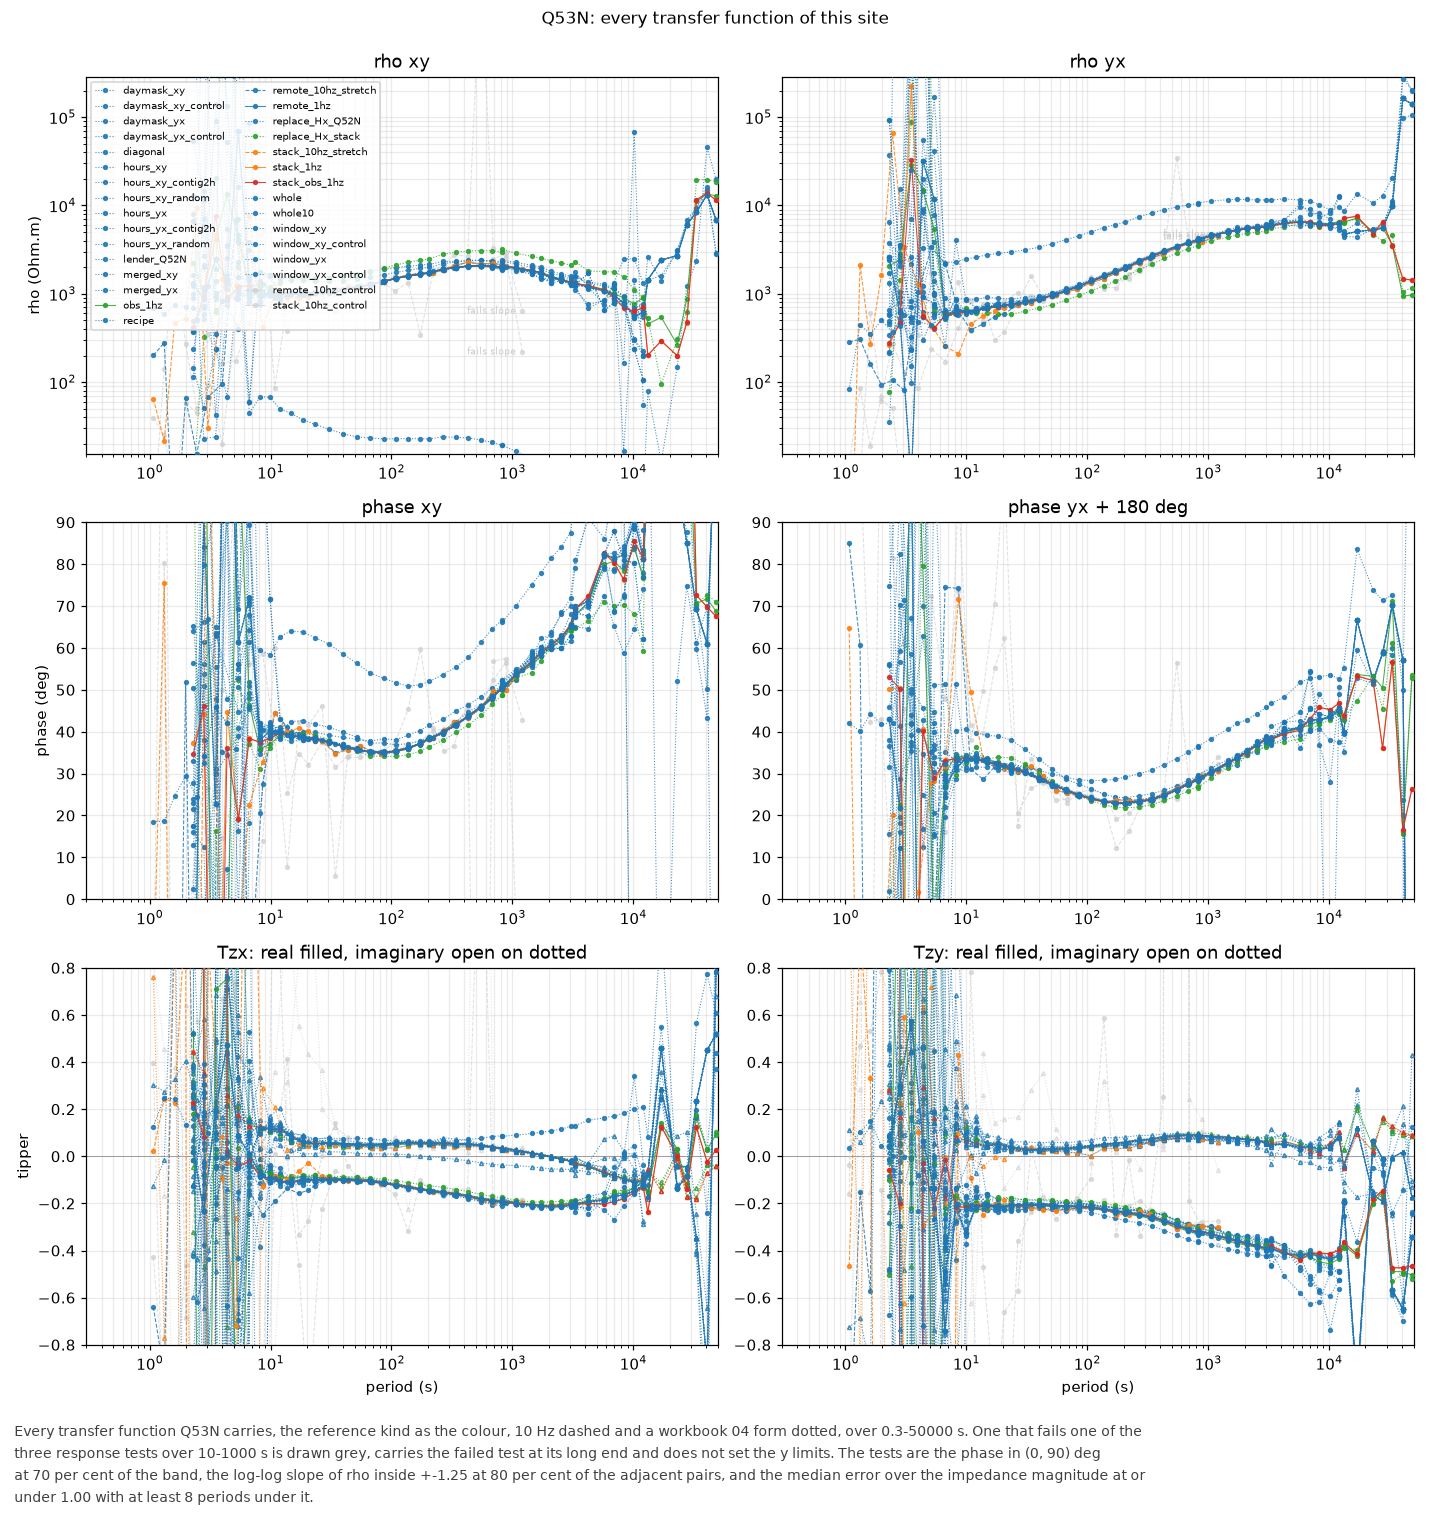

VERDICT: PASS -- all 31 EDI(s) in the run folders are in the readings table or are among the 0 single transfer function(s) named and ignored, and every one of the 66 scored rows carries the three verdicts the file itself gives when the phase fraction, the slope fraction, the bar and the period count are worked out again


In [4]:
t_read = time.time()
READINGS = RD.readings_table(TFS, read=read, band=tuple(QUALITY_BAND), agree_band=tuple(AGREE_BAND),
                             agree_rho=AGREE_RHO, agree_phase=AGREE_PHASE, quadrant_min=QUADRANT_MIN,
                             slope_tol=SLOPE_TOL, slope_min=SLOPE_MIN, bar_max=BAR_MAX,
                             min_periods=MIN_PERIODS, held_bar_max=HELD_BAR_MAX)
print("%d reading(s) over %d transfer function(s) of %d site(s) in %.1f s"
      % (len(READINGS), len(TFS), len(CHOSEN), time.time() - t_read))
print()
SHOW = READINGS[READINGS.site == FOCUS].copy()
SHOW["held_band_s"] = ["%.4g-%.4g" % (a, b) if np.isfinite(a) and np.isfinite(b) else "none"
                       for a, b in zip(SHOW.held_lo_s, SHOW.held_hi_s)]
cols = ["component", "transfer_function", "rate_hz", "selection", "form", "phase_frac", "slope_frac", "bar",
        "n_periods", "held_band_s", "agree_kinds", "passes", "fails"]
print("every transfer function of %s, and what the three tests say of each" % FOCUS)
print(SHOW[cols].round(3).to_string(index=False))
print()
print("how many pass, per kind and selection, over %d site(s)" % len(CHOSEN))
print(READINGS[READINGS.status == "ok"].pivot_table(index=["kind", "selection"], columns="component",
                                                    values="passes", aggfunc="sum").to_string())
print()
print("which test a row failed, the leading one of each")
print(READINGS[(READINGS.status == "ok") & (~READINGS.passes.astype(bool))]
      .fails.str.split(" ").str[0].value_counts().to_string())

# the three tests worked out again from each EDI, not read back from the table above
in_table = {str(p).lower() for p in READINGS.path}
set_ignored = {str(p).lower() for p in IGNORED.path}
walked, missing, bad = 0, [], []
for folder in sorted({Path(p).parent for p in TFS.path}):
    for p in sorted(Path(folder).glob("*.edi")):
        walked += 1
        if str(p).lower() not in in_table and str(p).lower() not in set_ignored:
            missing.append(str(p))
for r in READINGS[READINGS.status == "ok"].itertuples():
    tf = read(r.path)
    i, j = TFN.COMPONENTS[r.component]
    per = np.asarray(tf.period, float)
    zz, ee = tf.z[:, i, j], np.asarray(tf.z_err, float)[:, i, j]
    with np.errstate(divide="ignore", invalid="ignore"):
        rel = np.where(np.isfinite(zz) & (np.abs(zz) > 0) & np.isfinite(ee), ee / np.abs(zz), np.nan)
    ph = np.degrees(np.angle(zz)) + (180.0 if r.component == "yx" else 0.0)
    ph = np.where(ph > 180, ph - 360, ph)
    rho = 0.2 * per * np.abs(zz) ** 2
    band = (per >= QUALITY_BAND[0]) & (per <= QUALITY_BAND[1])
    mp = band & np.isfinite(ph)
    qf = float(np.mean((ph[mp] > 0) & (ph[mp] < 90))) if mp.any() else np.nan
    ms = band & np.isfinite(rho) & (rho > 0)
    sl = (np.diff(np.log10(rho[ms])) / np.diff(np.log10(per[ms]))) if ms.sum() > 1 else np.zeros(0)
    sf = float(np.mean(np.abs(sl) <= 1.0 + SLOPE_TOL)) if len(sl) else np.nan
    me = band & np.isfinite(rel)
    bb = float(np.median(rel[me])) if me.any() else np.nan
    nn = int((rel[me] < BAR_MAX).sum())
    got = (bool(qf >= QUADRANT_MIN), bool(sf >= SLOPE_MIN), bool(bb <= BAR_MAX and nn >= MIN_PERIODS))
    if got != (bool(r.pass_phase), bool(r.pass_slope), bool(r.pass_error)):
        bad.append("%s %s %s: the table says %s, the file says %s"
                   % (r.site, r.component, r.transfer_function,
                      (bool(r.pass_phase), bool(r.pass_slope), bool(r.pass_error)), got))

drawn = []
for p, g in READINGS[(READINGS.site == FOCUS) & (READINGS.status == "ok")].groupby("path", sort=False):
    r0 = g.iloc[0]
    names = sorted({w.split(" ")[0] for s in g.fails for w in str(s).split("; ") if w})
    drawn.append(dict(tf=read(p), label=r0["transfer_function"], kind=r0.kind, rate_hz=r0.rate_hz,
                      form=r0.form, passes=bool(g.passes.all()),
                      fails=("fails %s" % ", ".join(names)) if names else ""))
fig_tfs = FIG.transfer_functions_page(
    FOCUS, drawn, final_dir(FOCUS) / ("%s_transfer_functions.png" % FOCUS),
    period_range=tuple(PERIOD_RANGE),
    title="%s: every transfer function of this site" % FOCUS,
    caption="Every transfer function %s carries, the reference kind as the colour, 10 Hz dashed and a "
            "workbook 04 form dotted, over %g-%g s. One that fails one of the three response tests over "
            "%g-%g s is drawn grey, carries the failed test at its long end and does not set the y limits. "
            "The tests are the phase in (0, 90) deg at %.0f per cent of the band, the log-log slope of rho "
            "inside +-%.2f at %.0f per cent of the adjacent pairs, and the median error over the impedance "
            "magnitude at or under %.2f with at least %d periods under it."
            % (FOCUS, PERIOD_RANGE[0], PERIOD_RANGE[1], QUALITY_BAND[0], QUALITY_BAND[1],
               100 * QUADRANT_MIN, 1.0 + SLOPE_TOL, 100 * SLOPE_MIN, BAR_MAX, MIN_PERIODS))
WRITTEN.append(fig_tfs)
display(Image(filename=str(fig_tfs)))

n_scored = int((READINGS.status == "ok").sum())
if not n_scored:
    print("VERDICT: UNJUDGED -- 0 of the %d row(s) in the readings table could be read, so nothing was "
          "scored" % len(READINGS))
elif missing or bad:
    print("VERDICT: FAIL -- %d of the %d EDI(s) in the run folders are missing from the readings table "
          "(%s); %d row(s) carry a verdict the file itself does not reproduce (%s)"
          % (len(missing), walked, "; ".join(Path(m).name for m in missing[:4]) or "none", len(bad),
             "; ".join(bad[:3]) or "none"))
else:
    print("VERDICT: PASS -- all %d EDI(s) in the run folders are in the readings table or are among the %d "
          "%s transfer function(s) named and ignored, and every one of the %d scored rows carries the three "
          "verdicts the file itself gives when the phase fraction, the slope fraction, the bar and the "
          "period count are worked out again" % (walked, len(IGNORED), RD.DROPPED_KIND, n_scored))


## 2. The rule's proposal

Per component, the transfer function of record as the rule chooses it: among the rows at the delivery rate
that pass the three tests and agree with at least one row of another reference kind over AGREE_BAND, the one
with the smallest bar over QUALITY_BAND, ties broken by the longest period held.

Corroboration comes from another kind because two references that share no magnetics cannot carry the same
noise into the estimate. Two transfer functions agree where the median departure in apparent resistivity is
within AGREE_RHO and the median departure in phase is within AGREE_PHASE; the departure is the median of the
absolute differences and not the difference of the medians, so a curve that wobbles about another by more
than the tolerance is not agreement.

The choice is made at the delivery rate, `RECORD_RATES`, which is 1 Hz. A 10 Hz pass of this survey stops
near 1,200 s and the row a long-period survey delivers has to cover the delivery band; the 10 Hz short end
enters the file through the join below, at 16 s, and not as the whole row.

Which rows may be delivered is workbook 04's call. A workbook 03 transfer function may always be delivered; a
form may only where its forms.csv row marks it a candidate, which it does where the form beats every control
it carries on the 10-1000 s bar by 20 per cent and is not an inter-site impedance, and for the assembled
recipe where every row it was built from that carries a control beat it and its frame holds. A form that is
not a candidate is read, scored and reported in section 1 and is drawn for comparison; it is never the
transfer function of record and it does not corroborate another row.

A component with no proposal is a finding: either its sound rows do not corroborate each other, so the
references disagree, or nothing passes the three tests, so the record carries no transfer function of that
orientation.

The figure draws the proposed curves with their error bars over the rows they were chosen against, each
rejected row named in grey. What to look for: a rejected curve lying on the chosen one says the choice was
between equals and the bar decided it; one parting from it at the long end says the references disagree where
the field is small.

This is the proposal, and section 3 is where it is accepted or replaced.

the rule's proposal, per site and component
site component transfer_function   kind_word     bar  n_periods  held_lo_s   held_hi_s  agree_n          agree_kinds
Q53N        xy         stack_1hz fleet stack 0.00115         20    8.16409 40815.76011        3 obs remote stack_obs
Q53N        yx         stack_1hz fleet stack 0.00093         20    6.68553 27748.26442        3 obs remote stack_obs

0 of 2 site-components have no proposal

what the proposal at Q53N was chosen among
  xy  stack_1hz               <- the smallest bar over 10-1000 s among the 1 Hz rows that pass the three response tests and agree with another kind over 5-200 s
     the sound rows and their bars: stack 1 Hz 0.0011; stack_obs 1 Hz 0.0012; remote 1 Hz 0.0014; obs 1 Hz 0.0016
  yx  stack_1hz               <- the smallest bar over 10-1000 s among the 1 Hz rows that pass the three response tests and agree with another kind over 5-200 s
     the sound rows and their bars: stack 1 Hz 0.0009; stack_obs 1 Hz 0.0009; remote

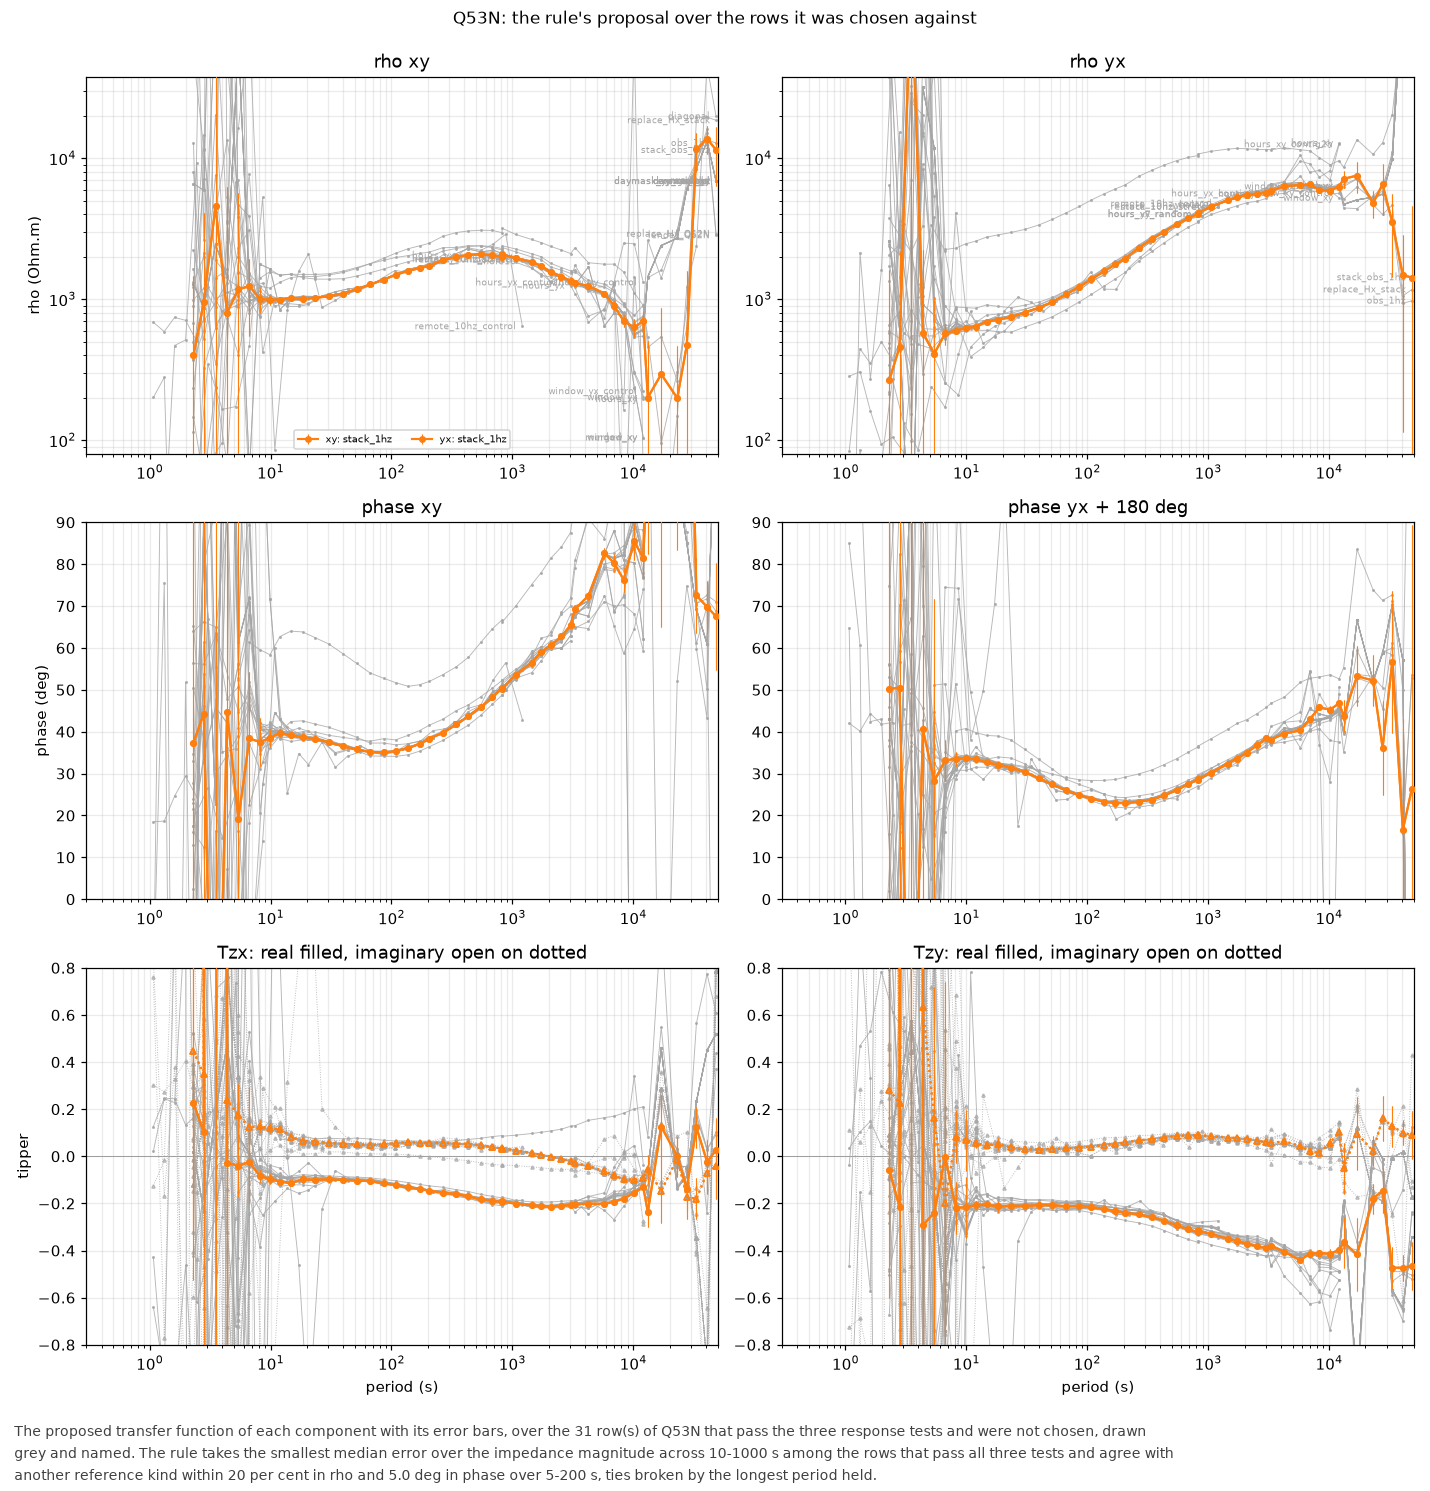

In [5]:
RECORD = RD.transfer_function_of_record(READINGS, agree_band=tuple(AGREE_BAND),
                                        band=tuple(QUALITY_BAND),
                                        rates=[float(r) for r in RECORD_RATES])
show = ["site", "component", "transfer_function", "kind_word", "bar", "n_periods", "held_lo_s", "held_hi_s",
        "agree_n", "agree_kinds"]
print("the rule's proposal, per site and component")
print(RECORD[show].round(5).to_string(index=False))
print()
NONE = RECORD[RECORD["transfer_function"] == "none"]
print("%d of %d site-components have no proposal" % (len(NONE), len(RECORD)))
if len(NONE):
    print(NONE[["site", "component", "why"]].to_string(index=False))
print()
print("what the proposal at %s was chosen among" % FOCUS)
for r in RECORD[(RECORD.site == FOCUS) & (RECORD["transfer_function"] != "none")].itertuples():
    print("  %s  %-22s  <- %s" % (r.component, r.transfer_function, r.why))
    print("     the sound rows and their bars: %s" % r.alternatives)
print()
AGREEMENT = pd.concat([RD.agreement_matrix(TFS[TFS.site == FOCUS], read=read, comp=c,
                                           agree_band=tuple(AGREE_BAND), agree_rho=AGREE_RHO,
                                           agree_phase=AGREE_PHASE)
                       for c in RD.COMPONENTS], ignore_index=True)
ex = AGREEMENT[(AGREEMENT.component == "xy") & (~AGREEMENT.same_kind)] if len(AGREEMENT) else AGREEMENT
if len(ex):
    print("%s, component xy: the median departure in rho between transfer functions of different kinds"
          % FOCUS)
    print(ex.pivot_table(index="a", columns="b", values="rho_dev").round(3).to_string())

USED = {str(r.path) for r in
        RECORD[(RECORD.site == FOCUS) & (RECORD["transfer_function"] != "none")].itertuples()}
REJECTED = {}
for r in READINGS[(READINGS.site == FOCUS) & READINGS.passes.astype(bool)].itertuples():
    if str(r.path) not in USED:
        REJECTED[r.transfer_function] = read(r.path)
PROPOSED = [("%s: %s" % (r.component, r.transfer_function), r.kind, read(r.path))
            for r in RECORD[(RECORD.site == FOCUS) & (RECORD["transfer_function"] != "none")].itertuples()]
if PROPOSED:
    fig_prop = FIG.over_rejected(
        FOCUS, PROPOSED, sorted(REJECTED.items()),
        final_dir(FOCUS) / ("%s_proposal.png" % FOCUS), period_range=tuple(PERIOD_RANGE),
        title="%s: the rule's proposal over the rows it was chosen against" % FOCUS,
        caption="The proposed transfer function of each component with its error bars, over the %d row(s) "
                "of %s that pass the three response tests and were not chosen, drawn grey and named. The "
                "rule takes the smallest median error over the impedance magnitude across %g-%g s among the "
                "rows that pass all three tests and agree with another reference kind within %.0f per cent "
                "in rho and %.1f deg in phase over %g-%g s, ties broken by the longest period held."
                % (len(REJECTED), FOCUS, QUALITY_BAND[0], QUALITY_BAND[1], 100 * AGREE_RHO, AGREE_PHASE,
                   AGREE_BAND[0], AGREE_BAND[1]))
    WRITTEN.append(fig_prop)
    display(Image(filename=str(fig_prop)))


### Reproducibility on halves

Each proposed transfer function is re-estimated twice, once on each half of its own record, and the two are
put through the agreement rule over QUALITY_BAND. One whose two halves disagree was estimated on something
that changed inside the record.

The record is not cut. Each half is a keep mask handed to the estimator on top of the transient mask, so the
mask is applied inside the pass and one Aurora run is written per kept stretch, exactly as the whole-record
pass was. The split is at the midpoint sample index, so the two halves are the same length whatever the gaps
hold; the days each half keeps after the transient mask are reported beside the verdict, because a record
whose second half is mostly masked reproduces on a shorter record than its first.

The cost is two passes per proposed transfer function, and only the proposed ones are run. `HALVES` False
reads the passes already on disk and leaves the reading UNJUDGED where there are none.

A transfer function that does not reproduce is flagged in the delivery record and is not removed: the rule
chose it on its soundness and its corroboration, and the reason it did not reproduce is written beside it for
a reader to weigh.

**This check fails if the halves are UNJUDGED for every proposed transfer function -- no half pass ran and
none was found on disk.** A reading over no items cannot support the column it fills.

The departures are two numbers per transfer function and are printed beside the proposal, not drawn: the
proposal table carries the median absolute departure in apparent resistivity and in phase between the two
halves, and the verdict names every transfer function that does not reproduce and the worst departure over
all of them.

In [6]:
import subprocess
import concurrent.futures as cf

CAND = RD.candidates(RECORD)
_stamps = sorted([s for s in {RD.split_run_folder(p.name)[1] for site in CHOSEN
                              for p in (WORK / site).glob("halves_*") if p.is_dir()} if s])
HALF_STAMP = _stamps[-1] if _stamps else datetime.now(timezone.utc).strftime("%Y%m%d_%H%M")
print("%d proposed transfer function(s), %d site lane job(s), stamp %s (%s)"
      % (len(CAND), CAND.groupby(["site", "rate_hz"]).ngroups if len(CAND) else 0, HALF_STAMP,
         "resumed" if _stamps else "new"))
print(CAND.to_string(index=False))

ENV = dict(os.environ)
ENV.update(OMP_NUM_THREADS="3", MKL_NUM_THREADS="3", OPENBLAS_NUM_THREADS="3")   # <- 3 threads a lane

def one_site(job):
    """One lane: every candidate kind of one site in turn. Two lanes on one site would share a scratch."""
    site, rate, kinds = job
    cmd = [sys.executable, "-m", "auslamp_proc.halves", "--survey", SURVEY, "--site", site,
           "--rate", str(int(rate)), "--stamp", HALF_STAMP, "--quiet", "--kinds"] + list(kinds)
    if WORK_ROOT:
        cmd += ["--work-root", str(WORK_ROOT)]
    t = time.time()
    r = subprocess.run(cmd, cwd=str(REPO), capture_output=True, text=True, env=ENV)
    return site, ",".join(kinds), r.returncode, round(time.time() - t, 1), (r.stderr or "").strip()[-200:]

t_half = time.time()
if HALVES and len(CAND):
    jobs = (CAND.groupby(["site", "rate_hz"])["kind"].apply(lambda v: sorted(set(v)))
            .reset_index().values.tolist())
    print()
    print("%d lane job(s) over %d lane(s); a half pass already on disk is reported and not remade"
          % (len(jobs), LANES), flush=True)
    done = 0
    with cf.ThreadPoolExecutor(max_workers=LANES) as ex:
        for site, kinds, rc, secs, err in ex.map(one_site, jobs):
            done += 1
            print("%2d/%2d %-9s %-22s exit %d %7.1f s %s" % (done, len(jobs), site, kinds, rc, secs,
                                                             err if rc else ""), flush=True)
HALF_RECORDS = []
for r in CAND.itertuples():
    rec = HV.read_existing(WORK, r.site, r.kind, int(r.rate_hz), stamp=HALF_STAMP,
                           band=tuple(QUALITY_BAND), agree_rho=AGREE_RHO, agree_phase=AGREE_PHASE)
    if rec is None:
        rec = dict(site=r.site, kind=r.kind, rate_hz=float(r.rate_hz), params="", stamp=HALF_STAMP,
                   half1="", half2="", half1_days=None, half2_days=None, seconds=None,
                   error="no half pass on disk", components={})
    HALF_RECORDS.append(rec)
HALF = HV.halves_table(HALF_RECORDS, out_path=OUT / "HALVES.csv")
WRITTEN.append(OUT / "HALVES.csv")
print()
print("%d proposed transfer function(s), two half passes each; %.1f min of wall time in this cell"
      % (len(CAND), (time.time() - t_half) / 60.0))
print(HALF[["site", "kind", "rate_hz", "component", "half1_days", "half2_days", "rho_dev",
            "phase_dev_deg", "n", "reproducible"]].round(4).to_string(index=False))
print()
print(HALF.reproducible.value_counts().to_string())

# the reading goes into the record beside the choice, never in place of it
rep = {(r.site, r.kind, r.component): (r.reproducible, r.why, r.rho_dev, r.phase_dev_deg)
       for r in HALF.itertuples()}
vals, whys, devs, dphs = [], [], [], []
for r in RECORD.itertuples():
    v, w, rd, pdg = rep.get((r.site, r.kind, r.component),
                            ("UNJUDGED", "no half pass for this row", np.nan, np.nan))
    vals.append(v if r.transfer_function != "none" else "")
    whys.append(w)
    devs.append(rd)
    dphs.append(pdg)
RECORD["reproducible"] = vals
RECORD["halves_rho_dev"] = devs
RECORD["halves_phase_dev_deg"] = dphs
RECORD["note"] = [("does not reproduce on halves: %s" % w) if v == "no" else n
                  for v, w, n in zip(vals, whys, RECORD.note)]
RECORD["flagged"] = [("not reproducible" if v == "no" else
                      ("halves UNJUDGED" if v == "UNJUDGED" else "")) for v in vals]
print()
print("the proposal with the split-half departures beside it")
print(RECORD[RECORD["transfer_function"] != "none"][
    ["site", "component", "transfer_function", "bar", "held_lo_s", "held_hi_s", "agree_n",
     "halves_rho_dev", "halves_phase_dev_deg", "reproducible"]].round(4).to_string(index=False))

judged = HALF[HALF.reproducible != "UNJUDGED"]
if not len(CAND):
    print("VERDICT: UNJUDGED -- 0 transfer functions were proposed, so there was nothing to re-estimate on "
          "halves")
elif not len(judged):
    print("VERDICT: UNJUDGED -- the halves were scored for 0 of the %d proposed transfer function(s): %s"
          % (len(CAND), "; ".join(sorted(set(HALF.why)))[:200]))
else:
    n_no = int((HALF.reproducible == "no").sum())
    print("VERDICT: PASS -- %d of %d reading(s) over the proposed transfer functions were scored on two "
          "half passes each; %d reproduce within %.0f %% in rho and %.1f deg in phase over %g-%g s and %d "
          "do not (%s); the worst departure over all of them is %.3f in rho and %.2f deg in phase, and a "
          "transfer function that does not reproduce is flagged in the delivery record and not removed"
          % (len(judged), len(HALF), len(judged) - n_no, 100 * AGREE_RHO, AGREE_PHASE, QUALITY_BAND[0],
             QUALITY_BAND[1], n_no,
             "; ".join("%s %s %.3f in rho, %.2f deg" % (r.site, r.component, r.rho_dev, r.phase_dev_deg)
                       for r in HALF[HALF.reproducible == "no"].itertuples()) or "none",
             float(np.nanmax(judged.rho_dev)), float(np.nanmax(judged.phase_dev_deg))))


1 proposed transfer function(s), 1 site lane job(s), stamp 20260916_2356 (resumed)
site  kind  rate_hz selection form   run         stamp components
Q53N stack      1.0     whole      first 20260916_1054      xy yx

1 lane job(s) over 2 lane(s); a half pass already on disk is reported and not remade


 1/ 1 Q53N      stack                  exit 0     2.9 s 



1 proposed transfer function(s), two half passes each; 0.0 min of wall time in this cell
site  kind  rate_hz component half1_days half2_days  rho_dev  phase_dev_deg  n reproducible
Q53N stack      1.0        xy       None       None   0.0405         0.4029 20          yes
Q53N stack      1.0        yx       None       None   0.0245         0.4251 20          yes

reproducible
yes    2

the proposal with the split-half departures beside it
site component transfer_function    bar  held_lo_s  held_hi_s  agree_n  halves_rho_dev  halves_phase_dev_deg reproducible
Q53N        xy         stack_1hz 0.0011     8.1641 40815.7601        3          0.0405                0.4029          yes
Q53N        yx         stack_1hz 0.0009     6.6855 27748.2644        3          0.0245                0.4251          yes
VERDICT: PASS -- 2 of 2 reading(s) over the proposed transfer functions were scored on two half passes each; 2 reproduce within 20 % in rho and 5.0 deg in phase over 10-1000 s and 0 do not (

### The 10 Hz join, as the splice rule chooses it

The delivered file is the 1 Hz row above SPLICE_JOIN_S and a 10 Hz row below it, where the step at the join
holds. Three measurements decide it, in this order.

**The decomposition first.** Each 10 Hz row is read against the 1 Hz row of the same kind over 4-32 s. The
median of that ratio over the kinds is the rate effect -- what the two processing paths say about the same
band -- and the spread across kinds at one rate is the kind effect. A survey whose rate effect exceeds 4 per
cent cannot be joined at all, because the join would deliver the difference between two processing paths as a
bend in the earth. Workbook 03 measures that departure on the survey's own whole-record 10 Hz passes and
writes it into every 10 Hz file; this is the measurement that says whether the survey has a short end to
deliver.

The gate is read over the whole-record 10 Hz pass and over the `control` stretch, and over no other row. The
`stretch` of the most coherent hours is not comparable to a 1 Hz row of the whole record: its departure over
4-32 s carries the selection as well as the rate, and a gate read over it would refuse the join for a
difference the join does not deliver. Every 10 Hz row is in the table beside the gate, with `in_gate` saying
which ones the median was taken over.

**The control gate.** The 10 Hz pass runs on the longest coherent stretch of whole UTC hours, so that stretch
has to earn its place against a run of the same length placed at random elsewhere in the record: a row is
eligible only where its 2-16 s impedance bar beats its own kind's `control` row by CONTROL_MARGIN. A
stretch that does not beat a random one of the same length has bought efficiency and not a different answer.
The whole-record 10 Hz pass is a control rather than a selection and is admitted without the gate; the `control`
row itself is never promoted; a `stretch` whose kind carries no `control` beside it is UNJUDGED on the gate
and is not eligible, and the table says so rather than passing it.

**The acceptance.** The step at the join is measured on two bands and the worse one governs: 8-16 s below,
where the delivered row would be the 10 Hz one, and 32-100 s above, where it is the 1 Hz one. A row whose
worse step exceeds SPLICE_MAX_STEP_PCT is reported not joined and keeps its 1 Hz row untouched. The band
between them is not scored: SPLICE_GUARD holds the Earth Data logger's 20.6 s instrument line, which is not
an earth response and is reproducible only to 5-14 per cent between honest processing paths, so a 2 per cent
criterion there would measure the line and not the join. The guard band is measured, printed and scored by
nothing.

Inside what the gate and the acceptance leave, the xy row is chosen on its 4-32 s level against the row it
joins and the yx row on its own short-end bar. Nothing below SHORT_FLOOR_S is delivered.

The step is read against the proposed transfer function of that same component, which is the row a 10 Hz pass
would join: the delivered row of a component is that transfer function's own row.

The numbers are printed and not drawn. The table below carries, per 10 Hz row, the departure on each ruled
band, the guard band, the 4-32 s level, the short-end bar, the control gate's verdict and `in_gate`, which
says whether the row is one of the two the survey-wide rate gate was read over. What to look for: a row whose
two ruled bands sit on opposite sides of zero is a row whose step is a bend and not an offset, and that is
what the two-band rule exists to catch; the guard band should scatter more widely than either ruled band,
which is why nothing scores it. The step of every row that was joined is scored again in section 4, from the
delivered file against the 1 Hz row it joined.

In [7]:
DEC = SP.decompose(TFS, read=read, band=tuple(SP.LEVEL_BAND), rate_max_pct=SP.RATE_PATH_MAX_PCT)
if len(DEC):
    print("the 10 Hz path against the 1 Hz path of the same kind over %g-%g s, in per cent"
          % SP.LEVEL_BAND)
    print(DEC.round(2).to_string(index=False))
    print()
    print("the rate against the kind")
    RATE = SP.rate_versus_kind(DEC, SP.RATE_PATH_MAX_PCT)
    print(RATE.round(2).to_string(index=False))
    RATE_OK = {r.component: bool(r.can_splice) for r in RATE.itertuples()}
    print("the rate path gate: %s"
          % ", ".join("%s %s (median %+.2f %%, the ceiling is %.0f %%)"
                      % (r.component, "passes" if r.can_splice else "REFUSES the join",
                         r.rate_pct_median, SP.RATE_PATH_MAX_PCT) for r in RATE.itertuples()))
else:
    RATE_OK = {}
    print("no site carries both a 1 Hz and a 10 Hz row of the same kind: there is no rate path to read")
print()

JOIN, SPLICE_SCORED = {}, []
for site in CHOSEN:
    proposed = picks_for(site, RECORD)
    shorts = {}
    for r in TFS[(TFS.site == site) & (TFS.rate_hz == 10.0) & TFS.on_disk].itertuples():
        shorts[(r.kind, r.selection, r.form)] = (read(r.path), r.path)
    for comp in RD.COMPONENTS:
        if comp not in proposed or not shorts:
            JOIN[(site, comp)] = dict(pick=None, scored=[], why=(
                "no 10 Hz transfer function of this site" if comp in proposed
                else "no transfer function of record on this component"))
            continue
        # the row a 10 Hz pass joins is the delivered row, and on this component that is the proposed
        # transfer function's own row, so the step is read against it and not against the other component's
        sel = SP.select_rows(site, read(proposed[comp]["path"]), shorts, READINGS, join=SPLICE_JOIN_S,
                             max_step_pct=SPLICE_MAX_STEP_PCT, guard=tuple(SPLICE_GUARD),
                             control_band=tuple(CONTROL_BAR_BAND), control_margin=CONTROL_MARGIN,
                             rate_ok=RATE_OK)
        JOIN[(site, comp)] = sel[comp]
        p = sel[comp]["pick"] or {}
        for c in sel[comp]["scored"]:
            SPLICE_SCORED.append(dict(site=site, component=comp, kind=c["kind"],
                                      selection=c["selection"], form=c.get("form", ""),
                                      file=Path(c["file"]).name,
                                      run=RD.split_run_folder(Path(c["file"]).parent.name)[0],
                                      in_gate=bool(c["selection"] in SP.GATE_SELECTIONS),
                                      passes=c["passes"], eligible=c["eligible"],
                                      control_verdict=c["control_verdict"],
                                      step_below_pct=c["step_below_pct"],
                                      step_above_pct=c["step_above_pct"], step_pct=c["step_pct"],
                                      guard_pct=c["guard_pct"], level_4_32_pct=c["level_4_32_pct"],
                                      short_bar=c["short_bar"],
                                      chosen=bool(p and c["file"] == p.get("file"))))
print("the join the splice rule proposes, per site and component")
for (site, comp), s in sorted(JOIN.items()):
    print("  %-8s %s  %s" % (site, comp, s.get("why", "")))
print()
SCORED = pd.DataFrame(SPLICE_SCORED)
if len(SCORED):
    SCORED.round(4).to_csv(OUT / "SPLICE_CANDIDATES.csv", index=False)
    WRITTEN.append(OUT / "SPLICE_CANDIDATES.csv")
    print("every 10 Hz row that was scored, %d of them; the departures are in per cent of the 1 Hz level "
          "over %g-%g s below the join, %g-%g s above it and %g-%g s in the guard band"
          % (len(SCORED), SP.STEP_BELOW[0], SP.STEP_BELOW[1], SP.STEP_ABOVE[0], SP.STEP_ABOVE[1],
             SPLICE_GUARD[0], SPLICE_GUARD[1]))
    print(SCORED[["site", "component", "kind", "selection", "form", "run", "in_gate", "passes",
                  "eligible", "step_below_pct", "step_above_pct", "guard_pct", "level_4_32_pct",
                  "short_bar", "chosen"]].round(3).to_string(index=False))
    print()
    print("the guard band over every row, measured and scored by nothing: median %+.1f %%, worst %+.1f %%"
          % (float(SCORED.guard_pct.median()),
             float(SCORED.guard_pct.iloc[int(np.nanargmax(np.abs(SCORED.guard_pct.values)))])))


the 10 Hz path against the 1 Hz path of the same kind over 4-32 s, in per cent
site   kind   kind_word selection    form component band_s  rate_pct  n  inside
Q53N remote remote site   control                xy   4-32    -33.84 10   False
Q53N remote remote site   control                yx   4-32    -20.00 10   False
Q53N remote remote site     whole whole10        xy   4-32     -3.32 10    True
Q53N remote remote site     whole whole10        yx   4-32      0.54 10    True
Q53N remote remote site   stretch                xy   4-32     -6.40 10   False
Q53N remote remote site   stretch                yx   4-32    -23.10 10   False
Q53N  stack fleet stack   control                xy   4-32    -21.39 10   False
Q53N  stack fleet stack   control                yx   4-32      2.92 10    True
Q53N  stack fleet stack   stretch                xy   4-32     -4.12 10   False
Q53N  stack fleet stack   stretch                yx   4-32    -11.84 10   False

the rate against the kind
component  n  

## 3. The choice

The cell below is the analyst's. `transfer_function` is `"rule"` or a name from the table of section 1;
`periods` is `"held"` or a pair `(lo_s, hi_s)`; `join` is `"rule"`, `None` for no 10 Hz row, or a period in
s. The tipper takes `"rule"`, which is TIPPER_FROM, or a component.

The delivery is rebuilt from the choice and not from the proposal; the two agree wherever the cell says
`"rule"`. Every departure is written into the delivered file's header as a `choice=` line and into
`surveys/<SURVEY>/final_choices.csv`, which this workbook reads before it proposes anything. A row there
marked `analyst` binds and is never overwritten by the rule; a row marked `rule` is refreshed. This run
writes the rows of this site and leaves every other site's as they stand.

The tipper is refused where the vertical channel is not measuring the vertical field: Hz a copy of a
horizontal channel, which reads a coherence of 1.00 with Hx, or Hz carrying the site's own horizontal field
at 1000-4000 s while carrying nothing of a neighbour's vertical field. The test runs at every site that
delivers, and a refused tipper is not written. A site whose magnetics are under 80 per cent finite is a test
that ran and could not judge; the tipper is written and the count is printed beside the verdict.

**This check fails if a chosen transfer function does not pass the three tests, if chosen periods fall
outside its held band without TRIM_TO_HELD False being set, if the merged file does not read back equal to
its sources, or if the tipper refusal test was not run.**

The choice is a table and not a figure: where it is the rule's, section 2 has already drawn it against the
rows it was made among, and where it is not, the departure is named here and written into the delivered
file's header. The chosen curve itself is drawn in section 4, which is the file it becomes.

In [8]:
CHOICE = dict(xy=dict(transfer_function="rule", periods="held", join="rule"),
              yx=dict(transfer_function="rule", periods="held", join="rule"),
              tipper=dict(transfer_function="rule"))


In [9]:
RULE_SPEC = dict(transfer_function="rule", periods="held", join="rule")

def _f(x):
    try:
        return float(x)
    except (TypeError, ValueError):
        return np.nan

def spec_for(site, comp):
    """(the choice in force, who made it, its note): an analyst row first, then the cell, then the rule."""
    a = CHOICES[(CHOICES.site == site) & (CHOICES.component == comp) & (CHOICES.chosen_by == "analyst")]
    if len(a):
        r = a.iloc[0]
        lo, hi, j = _f(r.periods_lo), _f(r.periods_hi), _f(r["join"])
        return (dict(transfer_function=str(r["transfer_function"]),
                     periods=((lo, hi) if np.isfinite(lo) and np.isfinite(hi) else "held"),
                     join=(j if np.isfinite(j) else None)), "analyst", str(r.note or ""))
    return dict(CHOICE.get(comp, RULE_SPEC)), "rule", ""

def row_named(site, comp, name):
    """The readings row a name picks out at one site and component, or None."""
    g = READINGS[(READINGS.site == site) & (READINGS.component == comp) & (READINGS.status == "ok")
                 & (READINGS["transfer_function"] == str(name))]
    if not len(g):
        return None
    r = g.sort_values("bar").iloc[0]
    return dict(path=r.path, kind=r.kind, kind_word=r.kind_word, form=r.form, selection=r.selection,
                run=r.run, stamp=r.stamp, rate_hz=float(r.rate_hz), bar=float(r.bar),
                held_lo_s=_f(r.held_lo_s), held_hi_s=_f(r.held_hi_s),
                transfer_function=str(r["transfer_function"]), passes=bool(r.passes))

MERGES, TIPPER_ONLY, DELIVERED, SPLICE_ROWS, IDENTITY = [], [], {}, [], []
CHOICE_ROWS, DEPART, REFUSAL, OUTSIDE, NOT_SOUND = [], [], {}, [], []
t_merge = time.time()
for site in CHOSEN:
    rule_picks = picks_for(site, RECORD)
    picks, bands, joins, lines, made_by = {}, {}, {}, [], {}
    for comp in RD.COMPONENTS:
        spec, by, note = spec_for(site, comp)
        want = str(spec.get("transfer_function", "rule") or "rule")
        pick = rule_picks.get(comp) if want in ("", "rule") else row_named(site, comp, want)
        if pick is None:
            if want not in ("", "rule"):
                DEPART.append("%s %s: %s names no transfer function of this site, so the row is empty"
                              % (site, comp, want))
            continue
        if want in ("", "rule"):
            g = READINGS[(READINGS.site == site) & (READINGS.component == comp)
                         & (READINGS.path == pick["path"])]
            pick["passes"] = bool(len(g) and bool(g.iloc[0].passes))
        held = (_f(pick.get("held_lo_s")), _f(pick.get("held_hi_s")))
        per = spec.get("periods", "held")
        if isinstance(per, str):
            band = (held if TRIM_TO_HELD and np.isfinite(held[0]) and np.isfinite(held[1]) else None)
        else:
            band = (float(per[0]), float(per[1]))
            if np.isfinite(held[0]) and np.isfinite(held[1]) and (band[0] < held[0] or band[1] > held[1]):
                OUTSIDE.append("%s %s: %g-%g s asked for, %g-%g s held"
                               % (site, comp, band[0], band[1], held[0], held[1]))
            DEPART.append("%s %s: periods %g-%g s instead of the held band"
                          % (site, comp, band[0], band[1]))
            lines.append("choice_%s_periods=%g-%g s, chosen by the analyst" % (comp, band[0], band[1]))
        j = spec.get("join", "rule")
        prop = JOIN.get((site, comp)) or {}
        if isinstance(j, str) and j.strip().lower() == "rule":
            joins[comp] = (prop.get("pick"), float(SPLICE_JOIN_S), prop.get("why", ""))
        elif j is None:
            joins[comp] = (None, float(SPLICE_JOIN_S),
                           "the choice cell asks for no 10 Hz row on this component")
            DEPART.append("%s %s: no 10 Hz row, against the rule's proposal" % (site, comp))
            lines.append("choice_%s_join=none, chosen by the analyst" % comp)
        else:
            joins[comp] = (prop.get("pick"), float(j),
                           "the choice cell joins at %g s; %s" % (float(j), prop.get("why", "")))
            DEPART.append("%s %s: join at %g s instead of %g s" % (site, comp, float(j), SPLICE_JOIN_S))
            lines.append("choice_%s_join=%g s, chosen by the analyst" % (comp, float(j)))
        if want not in ("", "rule"):
            DEPART.append("%s %s: the transfer function %s instead of the rule's %s"
                          % (site, comp, want, (rule_picks.get(comp) or {}).get("transfer_function",
                                                                               "none")))
            lines.append("choice_%s=transfer function %s, chosen by the analyst%s"
                         % (comp, want, (": " + note) if note else ""))
        picks[comp], bands[comp], made_by[comp] = pick, band, (by, note)
    if not picks:
        continue
    try:
        REFUSAL[site] = DL.tipper_refusal(sv, site)
    except Exception as exc:
        REFUSAL[site] = dict(site=site, judged=False, refused=False,
                             reason="the refusal test could not run: %s" % str(exc)[:120])
    refused = bool(REFUSAL[site].get("refused"))
    tspec = str((CHOICE.get("tipper") or {}).get("transfer_function", "rule"))
    tip = None if refused else (TIPPER_FROM if tspec in ("", "rule") else tspec)
    lines.append("tipper_refusal=%s (Hz with its own Hx %.2f, with its own H %.2f, with %s's Hz %.2f)"
                 % (REFUSAL[site].get("reason", ""), _f(REFUSAL[site].get("coh_hz_hx")),
                    _f(REFUSAL[site].get("coh_hz_own_h")), REFUSAL[site].get("neighbour", "none"),
                    _f(REFUSAL[site].get("coh_hz_neighbour_hz"))))
    base_path = final_dir(site) / ("%s_1hz.edi" % site)
    m = FN.merge(sv, site, picks, base_path, tipper_from=tip, record=RECORD, keep_band=bands,
                 extra_lines=lines, verbose=False)
    m["picks"] = picks
    MERGES.append(m)
    if not m.get("written"):
        continue
    joined = {c: (v[0] if v and v[0] else None) for c, v in joins.items()}
    join_s = next((v[1] for c, v in joins.items() if v[0]), float(SPLICE_JOIN_S))
    out_path = final_dir(site) / ("%s.edi" % site)
    res = SP.splice(base_path, {c: v for c, v in joined.items() if v}, out_path, join=join_s,
                    floor=SHORT_FLOOR_S, guard=tuple(SPLICE_GUARD))
    ident = SP.unspliced_unchanged(base_path, out_path, spliced=res["spliced"])
    ident.update(site=site, spliced=" ".join(res["spliced"]) or "none",
                 periods_added=res["periods_added"])
    IDENTITY.append(ident)
    DELIVERED[site] = out_path
    m["delivered"] = str(out_path)
    m["n_delivered_periods"] = int(len(TFN.read_tf(out_path).period)) if out_path.exists() else 0
    for comp in RD.COMPONENTS:
        p = joined.get(comp) or {}
        SPLICE_ROWS.append(dict(site=site, component=comp, spliced=bool(p), kind=p.get("kind", ""),
                                kind_word=p.get("kind_word", ""), selection=p.get("selection", ""),
                                form=p.get("form", ""), control_verdict=p.get("control_verdict", ""),
                                bar_2_16=p.get("bar_2_16", np.nan),
                                control_bar_2_16=p.get("control_bar_2_16", np.nan),
                                step_pct=p.get("step_pct", np.nan),
                                step_below_pct=p.get("step_below_pct", np.nan),
                                step_above_pct=p.get("step_above_pct", np.nan),
                                guard_pct=p.get("guard_pct", np.nan),
                                level_4_32_pct=p.get("level_4_32_pct", np.nan),
                                short_bar=p.get("short_bar", np.nan), passes=p.get("passes", False),
                                join_s=(join_s if p else np.nan),
                                shortest_period_s=p.get("shortest_period_s", np.nan),
                                n_short_periods=p.get("n_short_periods", 0),
                                why=(joins.get(comp) or (None, 0.0, ""))[2], all_kinds="",
                                file=p.get("file", "")))
    for comp, pick in sorted(picks.items()):
        by, note = made_by[comp]
        CHOICE_ROWS.append(FN.choice_row(site, comp, pick["transfer_function"], periods=bands.get(comp),
                                         join=(join_s if joined.get(comp) else None), chosen_by=by,
                                         note=note))
    CHOICE_ROWS.append(FN.choice_row(site, "tipper", (m.get("tipper_from") or "refused"), periods=None,
                                     join=None, chosen_by="rule",
                                     note=str(REFUSAL[site].get("reason", ""))))
    NOT_SOUND += ["%s %s: %s fails the three response tests" % (site, c, v["transfer_function"])
                  for c, v in picks.items() if not v.get("passes", True)]

SPLICE = SP.splice_table(SPLICE_ROWS)
print("%d site(s) merged and joined in %.1f min" % (len(MERGES), (time.time() - t_merge) / 60.0))
print()
print("the choice, per site and component")
print(pd.DataFrame(CHOICE_ROWS)[["site", "component", "transfer_function", "periods_lo", "periods_hi",
                                 "join", "chosen_by", "note"]].round(3).to_string(index=False)
      if CHOICE_ROWS else "nothing was chosen")
print()
print("%d departure(s) from the rule" % len(DEPART))
for d in DEPART:
    print("   %s" % d)
print()
print("the join, per site and component")
print(SPLICE[["site", "component", "spliced", "kind", "selection", "form", "join_s", "step_pct",
              "step_below_pct", "step_above_pct", "guard_pct", "level_4_32_pct", "short_bar",
              "shortest_period_s"]].round(3).to_string(index=False) if len(SPLICE) else "nothing joined")
print()
WROTE = FN.write_choices(FN.choices_path(sv), CHOICE_ROWS)
WRITTEN.append(WROTE["path"])
print("-> %s: %d row(s) written, %d analyst row(s) kept, %d row(s) in the file"
      % (WROTE["path"], WROTE["written"], WROTE["analyst_kept"], WROTE["rows"]))

bad_merge = [m["site"] for m in MERGES if not m.get("ok")]
# the criterion is that the test ran at every delivered site. A test that ran and could not judge -- a
# site whose magnetics are under 80 per cent finite -- is a stated reading and is reported beside the
# verdict, because the tipper it governs is still written and a reader has to know the test said nothing
not_run = [s for s in sorted(DELIVERED) if s not in REFUSAL]
unjudged = [s for s in sorted(DELIVERED) if s in REFUSAL and not REFUSAL[s].get("judged")]
outside = OUTSIDE if TRIM_TO_HELD else []
print()
print("the tipper refusal test: %d delivered site(s) judged, %d refused, %d not judged (%s)"
      % (len(DELIVERED) - len(unjudged) - len(not_run),
         sum(1 for s in DELIVERED if REFUSAL.get(s, {}).get("refused")), len(unjudged),
         "; ".join("%s: %s" % (s, REFUSAL[s].get("reason", "")) for s in unjudged) or "none"))
if not MERGES:
    print("VERDICT: UNJUDGED -- 0 of the %d site(s) carry a chosen row on either component, so nothing was "
          "chosen or merged" % len(CHOSEN))
elif NOT_SOUND or outside or bad_merge or not_run:
    print("VERDICT: FAIL -- %d chosen transfer function(s) do not pass the three response tests (%s); %d "
          "chosen band(s) fall outside the held band with TRIM_TO_HELD True (%s); %d merged file(s) do not "
          "read back equal to their sources (%s); the tipper refusal test was not run at %d delivered "
          "site(s) (%s)"
          % (len(NOT_SOUND), "; ".join(NOT_SOUND[:3]) or "none", len(outside),
             "; ".join(outside[:3]) or "none", len(bad_merge), " ".join(bad_merge) or "none",
             len(not_run), " ".join(not_run) or "none"))
else:
    print("VERDICT: PASS -- all %d chosen transfer function(s) over %d site(s) pass the three response "
          "tests, every chosen band lies inside its own held band, all %d merged file(s) read back with "
          "every row equal to its source to better than %.0e relative, and the tipper refusal test ran at "
          "all %d delivered site(s), refusing %d and judging %d of them"
          % (sum(len(m.get("picks") or {}) for m in MERGES), len(MERGES), len(MERGES), FN.READBACK_RTOL,
             len(DELIVERED), sum(1 for s in DELIVERED if REFUSAL.get(s, {}).get("refused")),
             len(DELIVERED) - len(unjudged)))


2026-09-18T03:48:08.670152+0800 | WARNING | mt_metadata.timeseries.survey | add_station | line: 624 | Station Q53N already exists, updating metadata


2026-09-18T03:48:08.670152+0800 | WARNING | mt_metadata.transfer_functions.io.emtfxml.emtfxml | _parse_comments | line: 808 | Cannot set attribute survey.summary.


2026-09-18T03:48:08.670152+0800 | WARNING | mt_metadata.transfer_functions.io.emtfxml.emtfxml | _parse_comments | line: 808 | Cannot set attribute original_program.version.


2026-09-18T03:48:08.670152+0800 | WARNING | mt_metadata.transfer_functions.io.emtfxml.emtfxml | _parse_comments | line: 808 | Cannot set attribute original_file.date.


2026-09-18T03:48:08.670152+0800 | WARNING | mt_metadata.transfer_functions.io.emtfxml.emtfxml | _parse_comments | line: 808 | Cannot set attribute survey.acquired_by.author.


...

2026-09-18T03:48:08.718388+0800 | WARNING | mt_metadata.transfer_functions.io.emtfxml.emtfxml | _parse_comments | line: 808 | Cannot set attribute q53na.hz.sensor.type.


2026-09-18T03:48:08.718388+0800 | WARNING | mt_metadata.transfer_functions.io.emtfxml.emtfxml | _parse_comments | line: 808 | Cannot set attribute q53na.hz.translated_azimuth.


2026-09-18T03:48:08.718388+0800 | WARNING | mt_metadata.transfer_functions.io.emtfxml.emtfxml | _parse_comments | line: 808 | Cannot set attribute q53na.hz.type.


2026-09-18T03:48:08.718388+0800 | WARNING | mt_metadata.transfer_functions.io.emtfxml.emtfxml | _parse_comments | line: 808 | Cannot set attribute q53na.hz.units.


1 site(s) merged and joined in 0.1 min

the choice, per site and component
site component transfer_function  periods_lo  periods_hi join chosen_by                note
Q53N        xy         stack_1hz       8.164   40815.760           rule                    
Q53N        yx         stack_1hz       6.686   27748.264   16      rule                    
Q53N    tipper                xy         NaN         NaN           rule neither fault fires

0 departure(s) from the rule

the join, per site and component
site component  spliced   kind selection    form  join_s  step_pct  step_below_pct  step_above_pct  guard_pct  level_4_32_pct  short_bar  shortest_period_s
Q53N        xy    False                              NaN       NaN             NaN             NaN        NaN             NaN        NaN                NaN
Q53N        yx     True remote     whole whole10    16.0    -0.888          -0.888            0.29      1.859           0.959      0.045              1.073

-> E:\MT_Timeseries_DATA

## 4. The delivered file

One file per site in `<work_root>/<site>/final/`. `<site>_1hz.edi` is the merge of the two chosen 1 Hz rows,
trimmed, and `<site>.edi` is the delivered file, which is that merge with any 10 Hz row joined below the join
period.

The merge takes the first impedance row (Zxx, Zxy) from the xy transfer function and the second (Zyx, Zyy)
from the yx transfer function, each with its errors, and the tipper from the one the choice names. A source
on another period grid is aligned by nearest period within 1 per cent and never interpolated: an interpolated
row is a third curve and not either source. A component with no chosen transfer function leaves its row empty
and the INFO block says so, so a reader cannot take an empty row for a measurement.

Under TRIM_TO_HELD the file carries the periods inside each row's chosen band and no others: a value outside
that band is dropped from its row, and a period left carrying neither off-diagonal element is dropped from
the grid with the tipper on it. Every dropped period is named in the manifest with the band that dropped it.
With TRIM_TO_HELD False every period the sources carry is written and the file's INFO block says it was not
trimmed.

A site with no impedance on either component can still deliver its tipper, which is an H-only quantity and
survives two dead electric lines. Its impedance rows are written as the EDI empty-data fill and two INFO
lines name what the file is.

The INFO block carries which transfer function each row came from, the flags and the notes per component,
the frame block, the trim line, the join line where a 10 Hz row is in the file, the cache it was built from,
the 10 Hz caveat, any `choice=` line and the package version and date. The frame is stated in three lines:
the tensor is served in the frame it was processed in, the IGRF declination is recorded and not applied, and
the angle to turn the tensor by for true geographic north is given with the transformation.

**This check fails if any merged file does not read back with its rows equal to its sources to 1e-9
relative, if the two-source control fails where the two sources carry different yx rows, if any period or
value of a row that was not joined differs from its 1 Hz input by more than 1e-12 relative, if a joined row
reads further than SPLICE_MAX_STEP_PCT from its 1 Hz row below the join or moves it above the join, or if
any delivered file lacks the frame block or the declination.** The two-source control is what says the merge
took rows from two files: the merged Zyx must differ from the xy source's wherever the two sources differ
there. The step is worked out again here from the files -- the joined 10 Hz file against the 1 Hz row it
joined below the join, and the delivered row against that same 1 Hz row above it -- so both numbers are
scored against the files and not against the table that proposed them.

The figure is the delivered curve with its own error bars and the join marked, and nothing behind it.


1 merged file(s), 0 tipper-only file(s), 0 site(s) with nothing to deliver
site     file    xy    yx tipper  periods  dropped readback check                                             control xml
Q53N Q53N.edi stack stack     xy       54        6  0.0e+00  PASS control n/a (the two source files share the yx row) yes

   Q53N     6 period(s) dropped, 2.303 to 4.847e+04 s: outside the delivered band (xy 8.16409-40815.8 s; yx 6.68553-27748.3 s), the tipper trimmed with the grid

every period and value of a row that was not joined, against its 1 Hz input
site spliced  periods_added  n_base_periods  n_out_periods  worst_period_relative  worst_value_relative   ok
Q53N      yx             12              42             54                    0.0                   0.0 True

the INFO block of Q53N
   reference_kind=fleet stack (stack)
   reference_coverage=0.9493 of the record carries a sound reference
   reference_weight_rule=fleet: each member is weighted by its median coherence with the fle

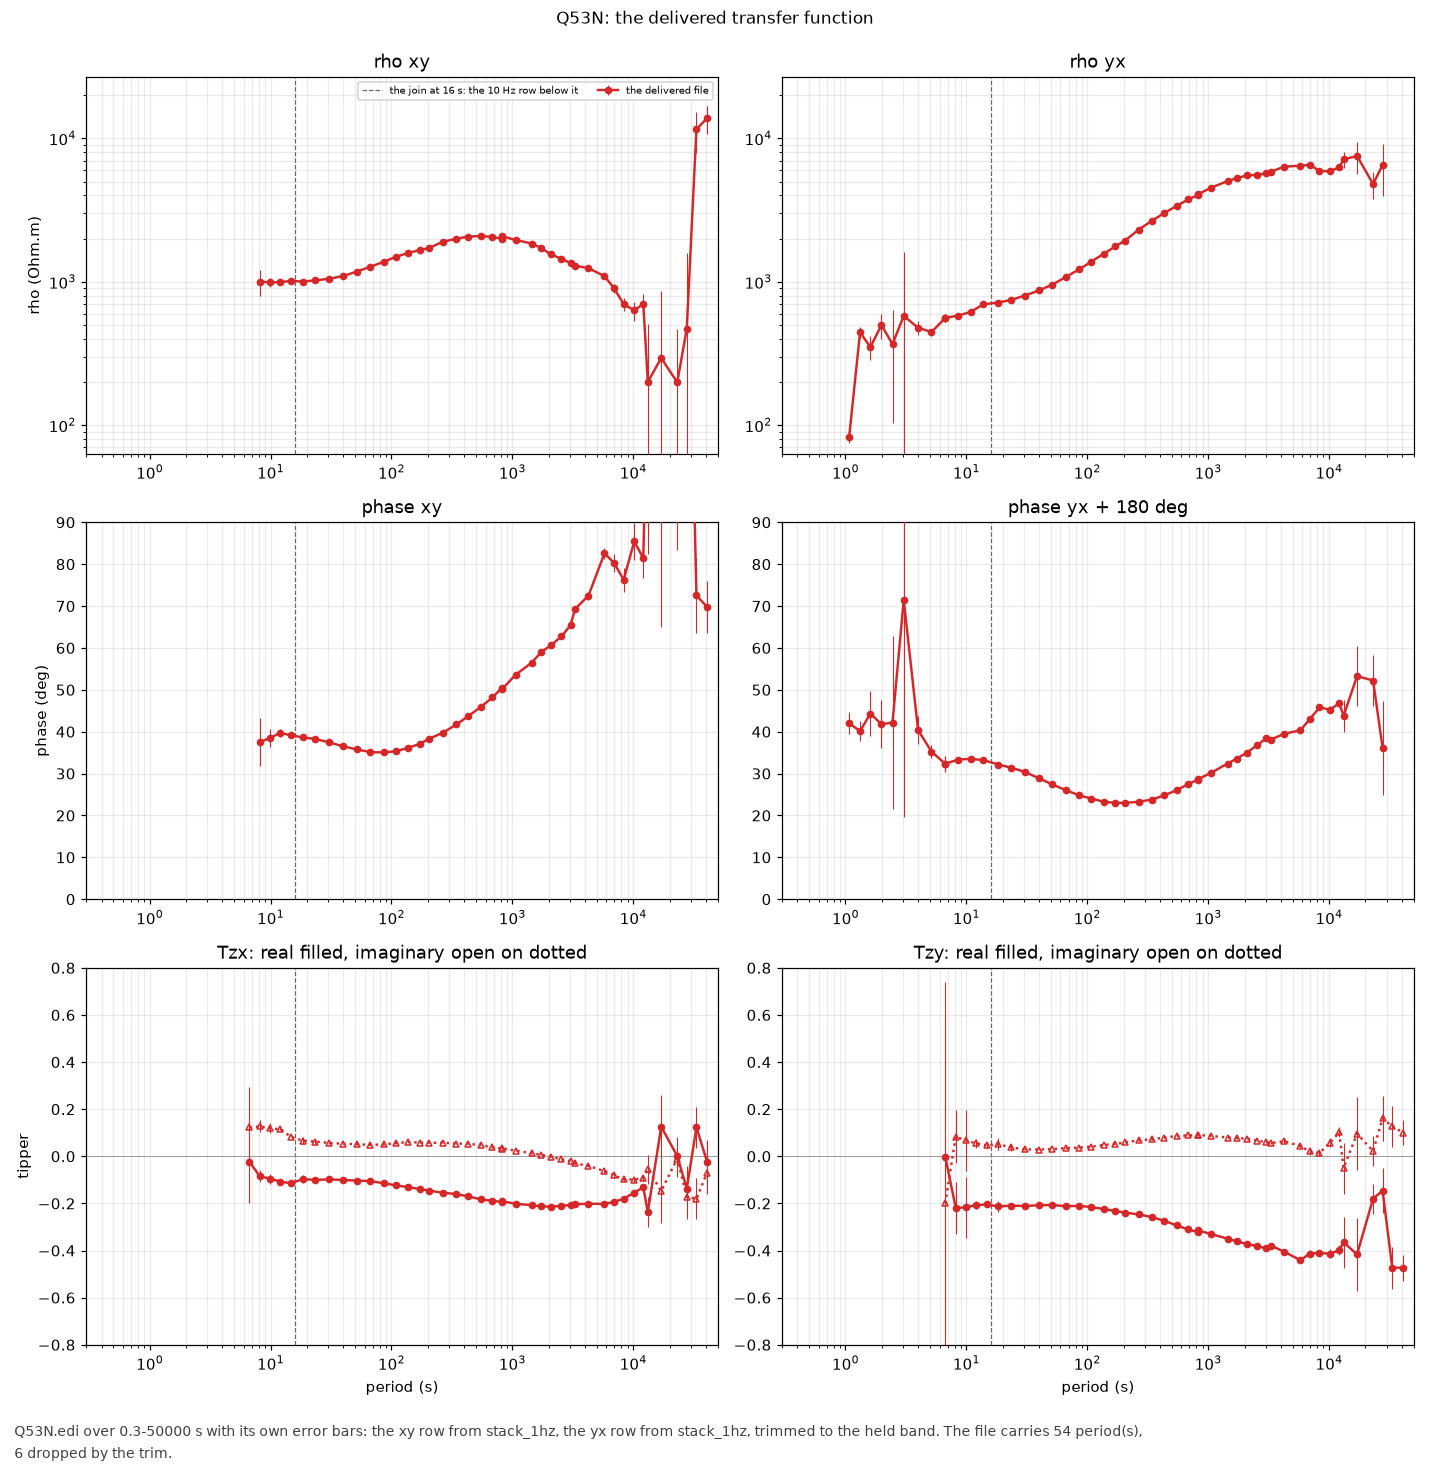


the join scored again from the files: the joined 10 Hz row against the 1 Hz row over 8-16 s, and the delivered row against the same 1 Hz row over 32-100 s
site component  join_s  step_below_pct  worst_above_relative  n_below
Q53N        yx    16.0         -0.8884                   0.0        4
VERDICT: PASS -- all 1 merged file(s) read back with every row equal to its source to better than 1e-09 relative; the two-source control holds at the 0 site(s) whose two sources carry different yx rows and is n/a at the other 1; every period and value of a row that was not joined came back identical to its 1 Hz input to better than 1e-12 relative over 1 file(s); each of the 1 joined row(s) reads inside 2.0 % of its 1 Hz row below the join and leaves that row untouched above it; all 1 delivered file(s) carry the frame, the declination and the angle to geographic north


In [10]:
for site in CHOSEN:
    if picks_for(site, RECORD) or site in DELIVERED:
        continue
    g = READINGS[(READINGS.site == site) & (READINGS.status == "ok") & (READINGS.rate_hz == 1.0)
                 & (READINGS.form == "")]
    if not len(g) or not g.bar.notna().any():
        continue
    src = g.loc[g.bar.idxmin()]
    if read(src.path).t is None:
        continue
    try:
        refusal = DL.tipper_refusal(sv, site)
    except Exception as exc:
        refusal = dict(site=site, judged=False, refused=False,
                       reason="the refusal test could not run: %s" % str(exc)[:120])
    REFUSAL[site] = refusal
    out = FN.tipper_only(sv, site, src.path, final_dir(site) / ("%s.edi" % site), kind=src.kind_word,
                         refusal=refusal, record=RECORD)
    out["picks"] = {"tipper": dict(path=src.path, kind=src.kind, form=src.form, run=src.run,
                                   stamp=src.stamp, rate_hz=src.rate_hz)}
    out["delivered"] = out.get("path")
    TIPPER_ONLY.append(out)
    if out.get("written"):
        DELIVERED[site] = Path(out["path"])
    print("   %-8s tipper only from the %s row: %s" % (site, src.kind_word, out.get("reason", "")))

print()
print("%d merged file(s), %d tipper-only file(s), %d site(s) with nothing to deliver"
      % (len(MERGES), len([t for t in TIPPER_ONLY if t.get("written")]), len(CHOSEN) - len(DELIVERED)))
mtab = pd.DataFrame([dict(site=m["site"], file=Path(m.get("delivered") or m["path"]).name,
                          xy=m.get("xy", ""), yx=m.get("yx", ""), tipper=m.get("tipper_from", ""),
                          periods=m.get("n_delivered_periods", 0), dropped=m.get("n_dropped", 0),
                          readback=("%.1e" % m.get("worst_readback_relative", np.nan)),
                          check=("PASS" if m.get("ok") else "FAIL"), control=m.get("control", ""),
                          xml=("yes" if m.get("xml") else ("no: " + str(m.get("xml_error", ""))[:40])))
                     for m in MERGES])
print(mtab.to_string(index=False) if len(mtab) else "no site was merged")
print()
for m in MERGES:
    if m.get("n_dropped"):
        gone = np.asarray(m.get("dropped_periods_s", []), float)
        print("   %-8s %d period(s) dropped, %.4g to %.4g s: %s"
              % (m["site"], len(gone), float(np.min(gone)), float(np.max(gone)),
                 m.get("dropped_reason", "")))
print()
IDENT = pd.DataFrame(IDENTITY)
if len(IDENT):
    print("every period and value of a row that was not joined, against its 1 Hz input")
    print(IDENT[["site", "spliced", "periods_added", "n_base_periods", "n_out_periods",
                 "worst_period_relative", "worst_value_relative", "ok"]].to_string(index=False))
print()
JOINED_AT = {r.site: float(r.join_s) for r in SPLICE.itertuples()
             if r.spliced and np.isfinite(r.join_s)} if len(SPLICE) else {}
if FOCUS in DELIVERED:
    print("the INFO block of %s" % FOCUS)
    for line in TFN.read_tf(DELIVERED[FOCUS]).meta["lines"]:
        print("   %s" % line)
    fig_del = FIG.delivered_page(
        FOCUS, read(DELIVERED[FOCUS]), final_dir(FOCUS) / ("%s_delivered.png" % FOCUS),
        period_range=tuple(PERIOD_RANGE), join_s=JOINED_AT.get(FOCUS),
        title="%s: the delivered transfer function" % FOCUS,
        caption="%s over %g-%g s with its own error bars: the xy row from %s, the yx row from %s, %s. The "
                "file carries %d period(s)%s."
                % (Path(DELIVERED[FOCUS]).name, PERIOD_RANGE[0], PERIOD_RANGE[1],
                   ", ".join("%s" % v["transfer_function"] for c, v in sorted(
                       (next((m for m in MERGES if m["site"] == FOCUS), {}).get("picks") or {}).items())
                       if c == "xy") or "none",
                   ", ".join("%s" % v["transfer_function"] for c, v in sorted(
                       (next((m for m in MERGES if m["site"] == FOCUS), {}).get("picks") or {}).items())
                       if c == "yx") or "none",
                   "trimmed to the held band" if TRIM_TO_HELD else "not trimmed",
                   int(len(read(DELIVERED[FOCUS]).period)),
                   (", %d dropped by the trim" % next((m.get("n_dropped", 0) for m in MERGES
                                                       if m["site"] == FOCUS), 0))))
    WRITTEN.append(fig_del)
    display(Image(filename=str(fig_del)))

no_frame = []
for site, p in sorted(DELIVERED.items()):
    kv = TFN.read_tf(p).meta["parameters"]
    lack = [k for k in ("reference_frame", "declination_deg", "to_geographic_north_deg")
            if not str(kv.get(k, "")).strip()]
    if lack:
        no_frame.append("%s: %s" % (site, ", ".join(lack)))
bad_merge = [m["site"] for m in MERGES if not m.get("ok")]
no_control = [m["site"] for m in MERGES if "control FAIL" in str(m.get("control", ""))]
shifted = [r.site for r in IDENT.itertuples() if not r.ok] if len(IDENT) else []
# the two numbers the join has to answer for, worked out here from the files and not from the table above.
# below the join: the 10 Hz file that was joined against the 1 Hz row it joined, the median ratio of
# apparent resistivity over the ruled band, which is the step. above it: the delivered row against the same
# 1 Hz row, which must be the same numbers, because a join must not move the row it joined onto.
STEP_BACK, over = [], []
for r in (SPLICE.itertuples() if len(SPLICE) else []):
    if not r.spliced or r.site not in DELIVERED or not str(r.file):
        continue
    pb, rb, _e, _ph, _pe = RD.curve(TFN.read_tf(final_dir(r.site) / ("%s_1hz.edi" % r.site)), r.component)
    ps, rs, _e2, _ph2, _pe2 = RD.curve(TFN.read_tf(r.file), r.component)
    pd_, rd_, _e3, _ph3, _pe3 = RD.curve(TFN.read_tf(DELIVERED[r.site]), r.component)
    mb = (pb >= SP.STEP_BELOW[0]) & (pb <= SP.STEP_BELOW[1]) & np.isfinite(rb) & (rb > 0)
    ms = np.isfinite(rs) & (rs > 0)
    v = np.exp(np.interp(np.log(pb[mb]), np.log(ps[ms]), np.log(rs[ms]),
                         left=np.nan, right=np.nan)) / rb[mb] if mb.any() and ms.any() else np.zeros(0)
    below = 100.0 * (float(np.median(v[np.isfinite(v)])) - 1.0) if np.isfinite(v).any() else np.nan
    ma = (pb >= SP.STEP_ABOVE[0]) & (pb <= SP.STEP_ABOVE[1]) & np.isfinite(rb) & (rb > 0)
    idx = [int(np.argmin(np.abs(pd_ - t))) for t in pb[ma]]
    above = (float(np.nanmax(np.abs(np.asarray(rd_)[idx] / rb[ma] - 1.0))) if idx else np.nan)
    STEP_BACK.append(dict(site=r.site, component=r.component, join_s=float(r.join_s),
                          step_below_pct=below, worst_above_relative=above, n_below=int(np.isfinite(v).sum())))
    if np.isfinite(below) and abs(below) > SPLICE_MAX_STEP_PCT:
        over.append("%s %s %+.1f %% below the join" % (r.site, r.component, below))
    if np.isfinite(above) and above > 1e-6:
        over.append("%s %s moved the 1 Hz row above the join by %.2e relative"
                    % (r.site, r.component, above))
if STEP_BACK:
    print()
    print("the join scored again from the files: the joined 10 Hz row against the 1 Hz row over %g-%g s, "
          "and the delivered row against the same 1 Hz row over %g-%g s"
          % (SP.STEP_BELOW[0], SP.STEP_BELOW[1], SP.STEP_ABOVE[0], SP.STEP_ABOVE[1]))
    print(pd.DataFrame(STEP_BACK).round(4).to_string(index=False))
if not MERGES and not TIPPER_ONLY:
    print("VERDICT: UNJUDGED -- 0 of the %d site(s) carry a chosen row on either component, so no file was "
          "written" % len(CHOSEN))
elif bad_merge or no_frame or shifted or over:
    print("VERDICT: FAIL -- %d merged file(s) do not read back equal to their sources to %.0e relative or "
          "fail the two-source control (%s; control failures %s); %d file(s) moved a period or a value of "
          "a row that was not joined (%s); %d joined row(s) do not hold %.1f %% at the join or moved the "
          "1 Hz row above it (%s); %d delivered file(s) lack a frame line (%s)"    # <- the join, rescored
          % (len(bad_merge), FN.READBACK_RTOL, " ".join(bad_merge) or "none",
             " ".join(no_control) or "none", len(shifted), " ".join(shifted) or "none",
             len(over), SPLICE_MAX_STEP_PCT, "; ".join(over[:4]) or "none",
             len(no_frame), "; ".join(no_frame) or "none"))
else:
    n_control = sum(1 for m in MERGES if "control PASS" in str(m.get("control", "")))
    print("VERDICT: PASS -- all %d merged file(s) read back with every row equal to its source to better "
          "than %.0e relative; the two-source control holds at the %d site(s) whose two sources carry "
          "different yx rows and is n/a at the other %d; every period and value of a row that was not "
          "joined came back identical to its 1 Hz input to better than %.0e relative over %d file(s); each "
          "of the %d joined row(s) reads inside %.1f %% of its 1 Hz row below the join and leaves that row "
          "untouched above it; all %d delivered file(s) carry the frame, the declination and the angle to "
          "geographic north"
          % (len(MERGES), FN.READBACK_RTOL, n_control, len(MERGES) - n_control, SP.IDENTITY_TOL,
             len(IDENT), len(STEP_BACK), SPLICE_MAX_STEP_PCT, len(DELIVERED)))


## 5. What was written

The delivery of this site is appended to the survey's four tables under `<work_root>/survey/`, which is
where the record of a survey accumulates one row per delivered site as the workbook is run site by site:
TRANSFER_FUNCTIONS_OF_RECORD.csv the proposal per component with its reason, READINGS.csv every transfer
function and every statistic it was read on, SPLICE.csv what was done to each row at the join, and
FINAL_MANIFEST.csv the sha256 of the delivered file and of every transfer function it came from. A re-run of
this site replaces that site's rows and leaves every other site's untouched.

In [11]:
REC_OUT = FN.write_record(OUT, RECORD, READINGS, MERGES + TIPPER_ONLY, splice=SPLICE, sites=CHOSEN)
WRITTEN += list(REC_OUT["written"].values())
MAN = REC_OUT["manifest"]
if RESAMPLE:
    for site, p in sorted(DELIVERED.items()):
        r = FN.resample(p, final_dir(site) / ("%s_resampled.edi" % site))
        WRITTEN.append(r["path"])
    print("%d file(s) also written on the ten-per-decade grid, beside the delivered file and never in "
          "place of it" % len(DELIVERED))
for name, p in sorted(REC_OUT["written"].items()):
    print("   %-24s %s" % (name, p))
print("   the manifest holds %d delivered file(s) of %s, %d of them written by this run"
      % (MAN[MAN.role == "final"].site.nunique(), sv.cfg["name"], len(DELIVERED)))
print()

rows = []
for p in list(WRITTEN) + [q for s in sorted(DELIVERED) for q in
                          (Path(DELIVERED[s]), Path(DELIVERED[s]).with_suffix(".xml"))]:
    p = Path(p)
    if p.exists():
        rows.append(dict(file=str(p), kb=round(p.stat().st_size / 1024, 1)))
files = pd.DataFrame(rows).drop_duplicates("file").sort_values("file")
print("%d files, %.1f MB, in %.1f minutes" % (len(files), files.kb.sum() / 1024, (time.time() - T0) / 60))
print(files.head(80).to_string(index=False))
if len(files) > 80:
    print("   ... and %d more" % (len(files) - 80))
print()
print("ignored: %d %s transfer function(s) on disk, read by nothing above" % (len(IGNORED), RD.DROPPED_KIND))
for p in sorted(IGNORED.path):
    print("   %s" % p)


   FINAL_MANIFEST.csv       E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\survey\FINAL_MANIFEST.csv
   READINGS.csv             E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\survey\READINGS.csv
   SPLICE.csv               E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\survey\SPLICE.csv
   TRANSFER_FUNCTIONS_OF_RECORD.csv E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\survey\TRANSFER_FUNCTIONS_OF_RECORD.csv
   the manifest holds 23 delivered file(s) of queensland_phase1, 1 of them written by this run

11 files, 2.0 MB, in 0.2 minutes
                                                                                              file     kb
E:\MT_Timeseries_DATA\MT_AusLAMP_GA\Processing_AusLAMP\surveys\queensland_phase1\final_choices.csv    3.7
                     E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q53N\final\Q53N.edi   29.1
           E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q53N\final\Q53N_delivered.pn